## Exploratory Data Analysis (EDA) is used to understand patterns, relationships, and click behavior in the dataset before model training.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/processed/avazu_processed.parquet"
data = pd.read_parquet(file_path)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
data.head()

,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,...,C18,C19,C20,C21,timestamp,day,hour_of_day,day_of_week,is_weekend,time_period
0,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,0,35,-1,79,2014-10-21,21,0,1,0,night
1,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,0,35,100084,79,2014-10-21,21,0,1,0,night
2,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,0,35,100084,79,2014-10-21,21,0,1,0,night
3,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,0,35,100084,79,2014-10-21,21,0,1,0,night
4,0,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,07d7df22,a99f214a,...,0,35,-1,157,2014-10-21,21,0,1,0,night


In [4]:
data.shape

(40428967, 28)

# Click Target Analysis

In [5]:
click_counts = data["click"].value_counts()
click_counts   

click
0    33563901
1     6865066
Name: count, dtype: int64

In [6]:
# Calculate percentage
Click_percentage = data["click"].value_counts(normalize=True) * 100
Click_percentage

click
0    83.019438
1    16.980562
Name: proportion, dtype: float64

In [7]:
# Overall Click-Through Rate
overall_ctr = data["click"].mean()
print(f"Overall CTR: {overall_ctr:.4f}")
print(f"Overall CTR Percentage: {overall_ctr * 100:.2f}%")

Overall CTR: 0.1698
Overall CTR Percentage: 16.98%


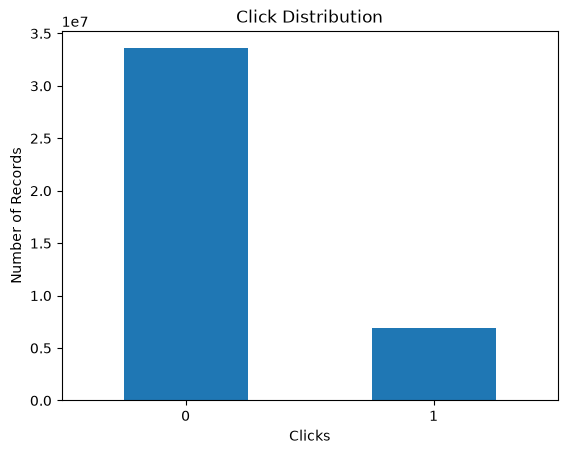

In [8]:
# Click distribution graph
click_counts.plot(kind="bar")
plt.title("Click Distribution")
plt.xlabel("Clicks")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

# Click Target Analysis

In [9]:
# Advertisement Impressions by Hour
# Counts the number of records in each group
hour_impressions = data.groupby("hour_of_day").size()
hour_impressions

hour_of_day
0      845178
1      984784
2     1222672
3     1399001
4     1913348
5     1982179
6     1762743
7     1857712
8     2096264
9     2276401
10    2149763
11    2052023
12    2216583
13    2388730
14    2203519
15    2081422
16    2050425
17    2029527
18    1758382
19    1318225
20    1120647
21     992963
22     907705
23     818771
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

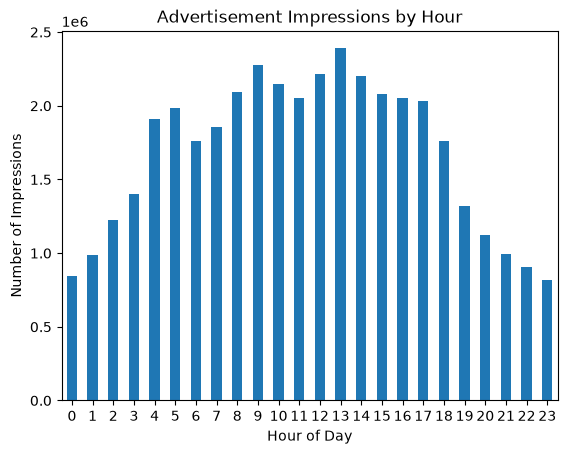

In [10]:
# Plot impressions by hour
hour_impressions.plot(kind="bar")
plt.title("Advertisement Impressions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Impressions")
plt.xticks(rotation=0)
plt.show

In [11]:
# CTR by Hour
ctr_by_hour = data.groupby("hour_of_day")["click"].mean()
ctr_by_hour

hour_of_day
0     0.180351
1     0.185774
2     0.176108
3     0.174199
4     0.159567
5     0.163387
6     0.168116
7     0.179190
8     0.163205
9     0.160104
10    0.161256
11    0.170437
12    0.170733
13    0.168434
14    0.177448
15    0.181210
16    0.179445
17    0.173265
18    0.168172
19    0.163996
20    0.160511
21    0.160666
22    0.163840
23    0.171842
Name: click, dtype: float64

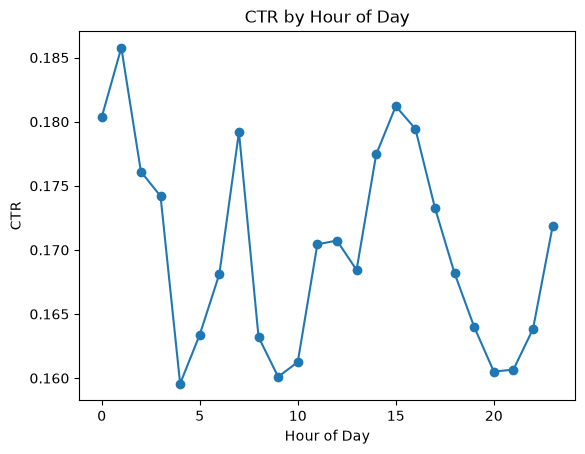

In [12]:
ctr_by_hour.plot(kind="line", marker="o")
plt.title("CTR by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("CTR")
plt.show()

In [13]:
# CTR by Day
ctr_by_day = data.groupby("day")["click"].mean()
ctr_by_day

day
21    0.174198
22    0.157167
23    0.182190
24    0.174716
25    0.182402
26    0.183049
27    0.181594
28    0.152182
29    0.156562
30    0.169281
Name: click, dtype: float64

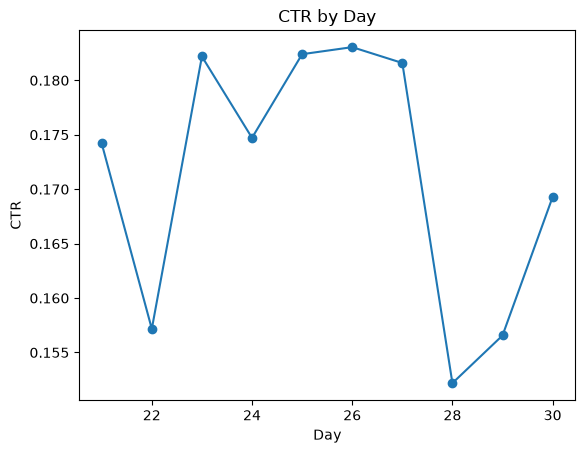

In [14]:
ctr_by_day.plot(kind="line", marker="o")
plt.title("CTR by Day")
plt.xlabel("Day")
plt.ylabel("CTR")
plt.show()

In [15]:
# CTR by Day of Week
ctr_by_day_of_week = data.groupby("day_of_week")["click"].mean()
ctr_by_day_of_week

day_of_week
0    0.181594
1    0.161828
2    0.156914
3    0.175457
4    0.174716
5    0.182402
6    0.183049
Name: click, dtype: float64

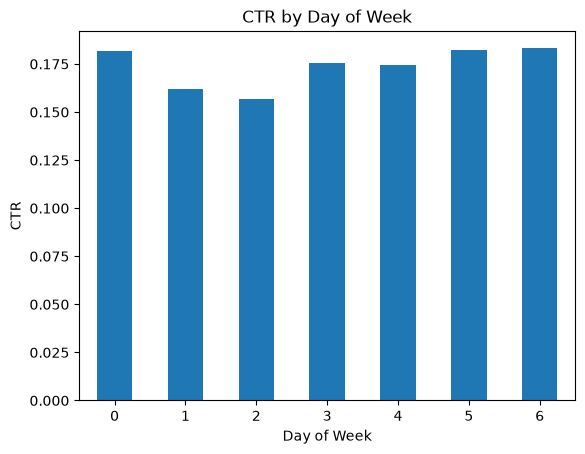

In [16]:
ctr_by_day_of_week.plot(kind="bar")
plt.title("CTR by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("CTR")
plt.xticks(rotation=0)
plt.show()

In [17]:
# CTR by Time Period
# The broader time periods created during feature engineering are analyzed.
# This helps identify general user activity patterns without analyzing every individual hour.
time_period_summary = (
    data.groupby("time_period").agg(
        impressions=("click", "size"),clicks=("click", "sum"),ctr=("click", "mean")
    )
)
time_period_summary

,impressions,clicks,ctr
time_period,,,
afternoon,12970206,2268557,0.174905
evening,6916693,1140722,0.164923
morning,12194906,2032213,0.166644
night,8347162,1423574,0.170546


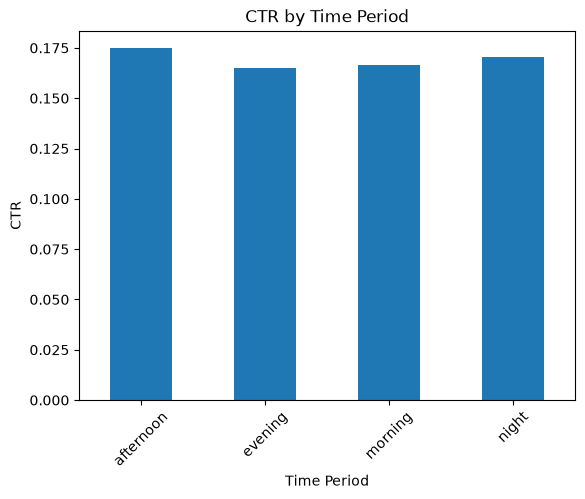

In [18]:
time_period_summary["ctr"].plot(kind="bar")
plt.title("CTR by Time Period")
plt.xlabel("Time Period")
plt.ylabel("CTR")
plt.xticks(rotation=45)
plt.show()

# Website-Level EDA

In [19]:
# Number of Unique Website Values
print("Unique site IDs:", data["site_id"].nunique())
print("Unique site domains:", data["site_domain"].nunique())
print("Unique site categories:", data["site_category"].nunique())

Unique site IDs: 4737
Unique site domains: 7745
Unique site categories: 26


In [20]:
# Top Site IDs by Impressions
top_sites = data["site_id"].value_counts().head(10)
top_sites

site_id
85f751fd    14596137
1fbe01fe     6486150
e151e245     2637747
d9750ee7      963745
5b08c53b      913325
5b4d2eda      771360
856e6d3f      765891
a7853007      461311
b7e9786d      369099
5ee41ff2      349008
Name: count, dtype: int64

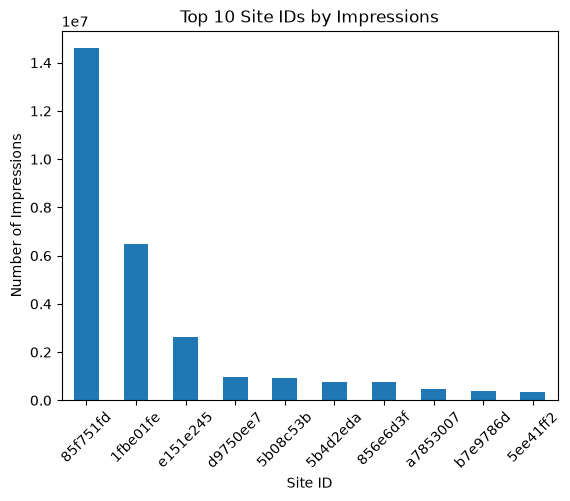

In [21]:
top_sites.plot(kind="bar")
plt.title("Top 10 Site IDs by Impressions")
plt.xlabel("Site ID")
plt.ylabel("Number of Impressions")
plt.xticks(rotation=45)
plt.show()

In [22]:
# CTR by Site Category
site_category_summary = (data.groupby("site_category").agg(
    impressions=("click", "size"),
    clicks=("click", "sum"),
    ctr=("click", "mean")
)
    .sort_values("impressions", ascending=False)
)
site_category_summary.head(10)

,impressions,clicks,ctr
site_category,,,
50e219e0,16537234,2126350,0.128580
f028772b,12657073,2272940,0.179579
28905ebd,7377208,1534600,0.208019
3e814130,3050306,863245,0.283003
f66779e6,252451,10019,0.039687
75fa27f6,160985,17915,0.111284
335d28a8,136463,12779,0.093644
76b2941d,104754,3170,0.030261
c0dd3be3,42090,4714,0.111998


# Application-Level EDA

In [23]:
print("Unique app IDs:", data["app_id"].nunique())
print("Unique app domains:", data["app_domain"].nunique())
print("Unique app categories:", data["app_category"].nunique())

Unique app IDs: 8552
Unique app domains: 559
Unique app categories: 36


In [24]:
# Top Application IDs
top_apps = data["app_id"].value_counts().head(10)
top_apps

app_id
ecad2386    25832830
92f5800b     1555283
e2fcccd2     1129016
febd1138      759098
9c13b419      757812
7358e05e      615635
a5184c22      491457
d36838b1      457572
685d1c4c      408515
54c5d545      397693
Name: count, dtype: int64

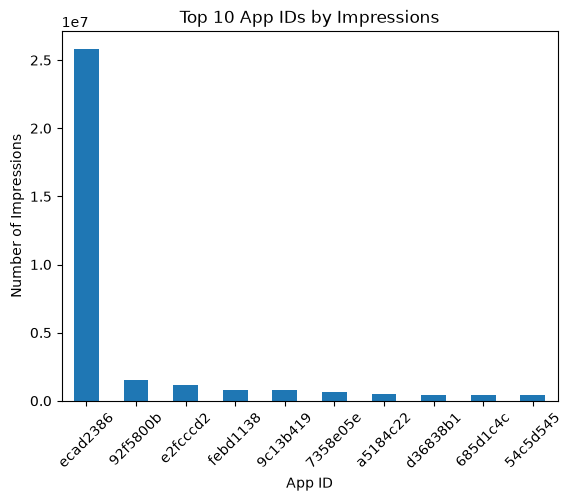

In [25]:
top_apps.plot(kind="bar")
plt.title("Top 10 App IDs by Impressions")
plt.xlabel("App ID")
plt.ylabel("Number of Impressions")
plt.xticks(rotation=45)
plt.show()

In [26]:
# CTR by App Category
app_category_summary = (data.groupby("app_category").agg(
    impressions=("click", "size"),
    clicks=("click", "sum"),
    ctr=("click", "mean")
)
    .sort_values("impressions", ascending=False)
)
app_category_summary.head(10)

,impressions,clicks,ctr
app_category,,,
07d7df22,26165592,5210822,0.199148
0f2161f8,9561058,1033720,0.108118
cef3e649,1731545,161450,0.093240
8ded1f7a,1467257,132021,0.089978
f95efa07,1141673,282664,0.247588
d1327cf5,123233,15197,0.123319
09481d60,54886,8518,0.155194
dc97ec06,54644,8552,0.156504
75d80bbe,40108,3849,0.095966


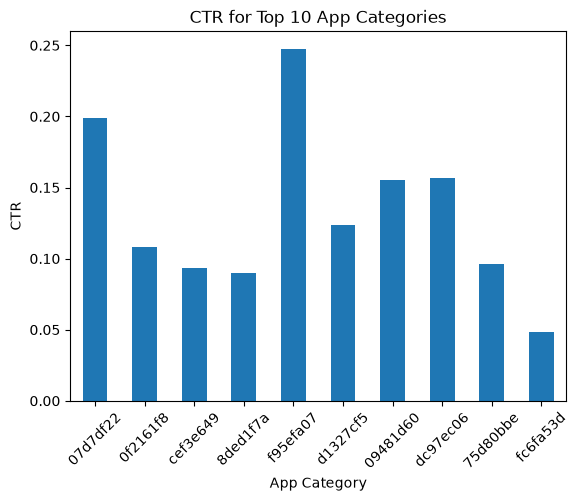

In [27]:
app_category_summary.head(10)["ctr"].plot(kind="bar")
plt.title("CTR for Top 10 App Categories")
plt.xlabel("App Category")
plt.ylabel("CTR")
plt.xticks(rotation=45)
plt.show()

# Device-Level EDA

In [28]:
device_columns = [
    "device_id",
    "device_ip",
    "device_model",
    "device_type",
    "device_conn_type"
]
for column in device_columns:
    print(column, ":", data[column].nunique())

device_id : 2686408
device_ip : 6729486
device_model : 8251
device_type : 5
device_conn_type : 4


In [29]:
# CTR by Device Type
device_type_summary = (data.groupby("device_type").agg(
    impressions=("click", "size"),
    clicks=("click", "sum"),
    ctr=("click", "mean")
)
)
device_type_summary

,impressions,clicks,ctr
device_type,,,
0,2220812,467995,0.210731
1,37304667,6311046,0.169176
2,31,2,0.064516
4,774272,73900,0.095444
5,129185,12123,0.093842


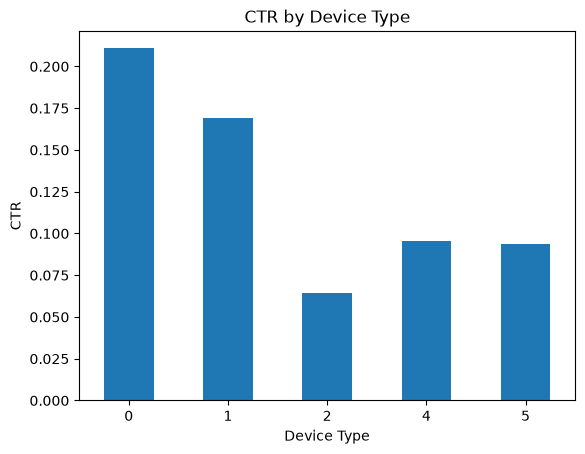

In [30]:
device_type_summary["ctr"].plot(kind="bar")
plt.title("CTR by Device Type")
plt.xlabel("Device Type")
plt.ylabel("CTR")
plt.xticks(rotation=0)
plt.show()

In [31]:
# CTR by Connection Type
connection_summary = (data.groupby("device_conn_type").agg(
    impressions=("click", "size"),
    clicks=("click", "sum"),
    ctr=("click", "mean")
)
)
connection_summary

,impressions,clicks,ctr
device_conn_type,,,
0,34886838,6318889,0.181125
2,3317443,448815,0.135289
3,2181796,96092,0.044043
5,42890,1270,0.029611


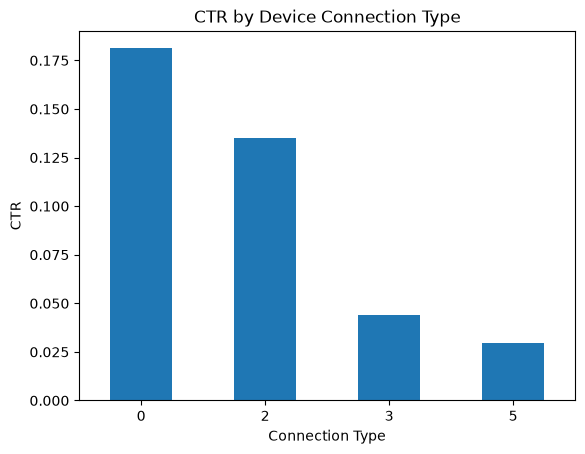

In [32]:
connection_summary["ctr"].plot(kind="bar")
plt.title("CTR by Device Connection Type")
plt.xlabel("Connection Type")
plt.ylabel("CTR")
plt.xticks(rotation=0)
plt.show()

In [33]:
# Top Device Models
top_device_models = data["device_model"].value_counts().head(10)
top_device_models

device_model
8a4875bd    2455470
1f0bc64f    1424546
d787e91b    1405169
76dc4769     767961
be6db1d7     742913
a0f5f879     652751
4ea23a13     645153
7abbbd5c     636673
ecb851b2     613048
d4897fef     483582
Name: count, dtype: int64

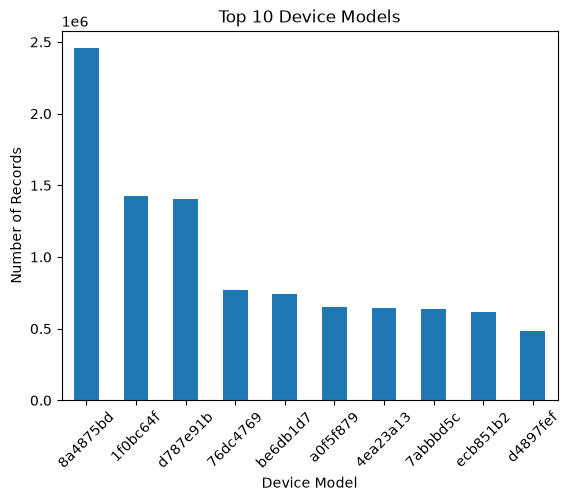

In [34]:
top_device_models.plot(kind="bar")
plt.title("Top 10 Device Models")
plt.xlabel("Device Model")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

# Advertisement Placement EDA

In [35]:
# Banner Impressions
banner_counts = data["banner_pos"].value_counts().sort_index()
banner_counts

banner_pos
0    29109590
1    11247282
2       13001
3        2035
4        7704
5        5778
7       43577
Name: count, dtype: int64

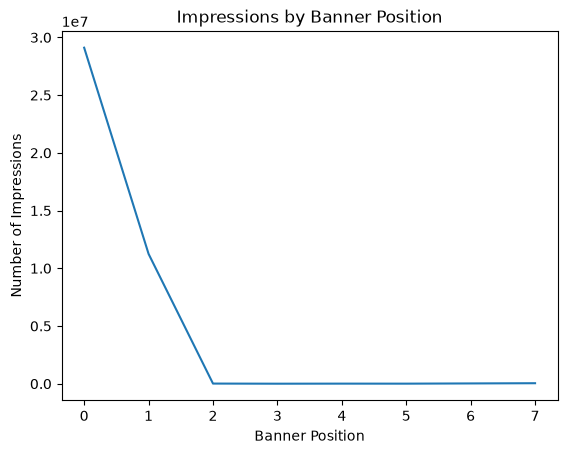

In [36]:
banner_counts.plot(kind="line")
plt.title("Impressions by Banner Position")
plt.xlabel("Banner Position")
plt.ylabel("Number of Impressions")
plt.xticks(rotation=0)
plt.show()

In [37]:
# CTR by Banner Position
banner_summary = (
    data.groupby("banner_pos").agg(
        impressions=("click", "size"),
        clicks=("click", "sum"),
        ctr=("click", "mean")
)
)
banner_summary


,impressions,clicks,ctr
banner_pos,,,
0,29109590,4781901,0.164272
1,11247282,2065164,0.183614
2,13001,1550,0.119222
3,2035,372,0.182801
4,7704,1428,0.185358
5,5778,702,0.121495
7,43577,13949,0.320100


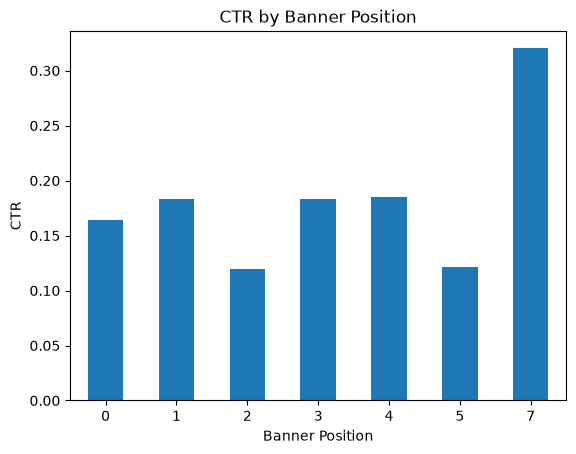

In [38]:
banner_summary["ctr"].plot(kind="bar")
plt.title("CTR by Banner Position")
plt.xlabel("Banner Position")
plt.ylabel("CTR")
plt.xticks(rotation=0)
plt.show()

In [39]:
# Anonymous Feature EDA
# The Avazu dataset contains anonymized categorical features from `C1` and `C14` to `C21`.
# Their exact business meanings are unknown.
# The features are therefore analyzed using their number of unique values, frequency, and CTR patterns.
anonymous_columns = ["C1","C14","C15","C16","C17","C18","C19","C20","C21"]
for column in anonymous_columns:
    print(column, ":", data[column].nunique())

C1 : 7
C14 : 2626
C15 : 8
C16 : 9
C17 : 435
C18 : 4
C19 : 68
C20 : 172
C21 : 60


# Frequency Distribution Analysis


In [40]:
# Device ID frequency
device_id_frequency = data["device_id"].value_counts()
device_id_frequency.head(10)

device_id
a99f214a    33358308
0f7c61dc       21356
c357dbff       19667
936e92fb       13712
afeffc18        9654
987552d1        4187
28dc8687        4101
d857ffbb        4004
cef4c8cc        3694
b09da1c4        3655
Name: count, dtype: int64

In [41]:
device_id_frequency.describe()

count    2.686408e+06
mean     1.504945e+01
std      2.035252e+04
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      3.335831e+07
Name: count, dtype: float64

In [42]:
# Device IP frequency
device_ip_frequency = data["device_ip"].value_counts()
device_ip_frequency.head(10)

device_ip
6b9769f2    208701
431b3174    135322
2f323f36     88499
af9205f9     87844
930ec31d     86996
af62faf4     85802
009a7861     85382
285aa37d     85313
6394f6f6     83184
d90a7774     82980
Name: count, dtype: int64

In [43]:
# App ID frequency
app_id_frequency = data["app_id"].value_counts()
app_id_frequency.head(10)

app_id
ecad2386    25832830
92f5800b     1555283
e2fcccd2     1129016
febd1138      759098
9c13b419      757812
7358e05e      615635
a5184c22      491457
d36838b1      457572
685d1c4c      408515
54c5d545      397693
Name: count, dtype: int64

In [44]:
# Site ID frequency
site_id_frequency = data["site_id"].value_counts()
site_id_frequency.head(10)

site_id
85f751fd    14596137
1fbe01fe     6486150
e151e245     2637747
d9750ee7      963745
5b08c53b      913325
5b4d2eda      771360
856e6d3f      765891
a7853007      461311
b7e9786d      369099
5ee41ff2      349008
Name: count, dtype: int64

# Rare Category Analysis
Rare categories are values that appear only a small number of times.
A large number of rare categories can increase feature complexity and affect encoding decisions.

In [45]:
device_id_counts = data["device_id"].value_counts()
rare_device_ids = device_id_counts[
    device_id_counts < 10
]
print("Total device IDs:", len(device_id_counts))
print("Rare device IDs:", len(rare_device_ids))

Total device IDs: 2686408
Rare device IDs: 2584960


In [46]:
rare_device_percentage = (
    len(rare_device_ids)/ len(device_id_counts)* 100
)
print(f"Rare Device ID Percentage: {rare_device_percentage:.2f}%")

Rare Device ID Percentage: 96.22%


In [47]:
# Device Type and Connection Type
device_connection_ctr = (data.groupby(["device_type", "device_conn_type"])["click"].mean().reset_index()
)
device_connection_ctr

,device_type,device_conn_type,click
0,0,0,0.210731
1,1,0,0.180203
2,1,2,0.137663
3,1,3,0.037714
4,1,5,0.029611
5,2,0,0.064516
6,4,0,0.091825
7,4,2,0.105319
8,4,3,0.091729
9,5,0,0.075156


# EDA Summary	
	1.The dataset is imbalanced, with significantly more non-clicked ads than clicked ads.
	2.Advertisement impressions vary by hour, showing that ad traffic changes throughout the day.
	3.CTR also changes by hour, day, and time period, indicating that time influences click behavior.
	4.Website and application traffic is concentrated in a small number of site IDs and app IDs.
	5.App categories show different CTR values, indicating differences in user engagement across application categories.
	6.Device type and connection type show noticeable differences in CTR.
	7.A small number of device models appear very frequently.
	8.Approximately 96.22% of unique device IDs appear fewer than 10 times, showing very high cardinality and many rare categories.
	9.The EDA supports using time-based features, frequency encoding, and device/context features for model training.
Final observation: The dataset contains clear time, application, website, and device-level patterns that can help predict advertisement clicks.	

In [48]:
eda_file_path = "../data/processed/avazu_eda_ready.parquet"
data.to_parquet(eda_file_path,index=False)
print("EDA-ready dataset saved successfully.")
print("File path:", eda_file_path)

EDA-ready dataset saved successfully.
File path: ../data/processed/avazu_eda_ready.parquet


In [ ]:
data.to_parquet()